## **Single Layer Perceptron Implementation Assignment**
Melinda Annastasia Budijono - 24/54280/PA/23052



**Deskripsi Proyek**

Notebook ini berisi implementasi **Single Layer Perceptron** yang dibangun secara matematis dari awal menggunakan bantuan *library* Numpy. Model ini dilatih menggunakan metode *Gradient Descent* untuk meminimalkan *Sum Squared Error* (SSE).



**Informasi Dataset**

Dataset yang digunakan adalah varian dari dataset bunga Iris dengan rincian sebagai berikut:
* **Fitur (Input):** Memiliki 4 variabel numerik (`X1`, `X2`, `X3`, `X4`).
* **Target (Label):** Klasifikasi biner yang dipetakan menjadi dua kelas utama:
  * `0` : Iris-setosa
  * `1` : Iris-versicolor

---
#### **1. Import Library & Persiapan Data**
Memuat library yang dibutuhkan, membaca dataset training dan validasi, memetakan label target, serta memisahkan variabel fitur (X) dan target (Y).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('dataset/slp-train.csv')
val_df = pd.read_csv('dataset/slp-val.csv')
 
label_map = {"Iris-setosa": 0, "Iris-versicolor": 1}
train_df["Target"] = train_df["Target"].map(label_map)

x_train = train_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_train = train_df["Target"].to_numpy()
x_val = val_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_val = val_df["Target"].to_numpy()

print(f"Total data Training: {len(train_df)} baris")
print(train_df["Target"].value_counts())
display(train_df.head(3))
display(train_df.tail(3))

print(f"Total data Validation: {len(val_df)} baris")
display(val_df.head(3))
display(val_df.tail(3))

Total data Training: 80 baris
Target
0    40
1    40
Name: count, dtype: int64


,X1,X2,X3,X4,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


,X1,X2,X3,X4,Target
77,6.3,2.3,4.4,1.3,1
78,5.6,3.0,4.1,1.3,1
79,5.5,2.5,4.0,1.3,1


Total data Validation: 20 baris


,No,X1,X2,X3,X4,Target
0,1,5.0,3.5,1.3,0.3,0
1,2,4.5,2.3,1.3,0.3,0
2,3,4.4,3.2,1.3,0.2,0


,No,X1,X2,X3,X4,Target
17,18,6.2,2.9,4.3,1.3,1
18,19,5.1,2.5,3.0,1.1,1
19,20,5.7,2.8,4.1,1.3,1


---
#### **2. Inisialisasi Parameter & Fungsi Matematis**
Menentukan *hyperparameter* awal (Learning Rate, Epochs), bobot model (*teta*), fungsi aktivasi Sigmoid, perhitungan Propagasi Maju (*Forward*), dan Gradien.

In [3]:
LEARNING_RATE = 0.1
EPOCHS = 5

teta = np.array([0.5, 0.5, 0.5, 0.5, 0.5]) 

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(teta, x_row):
    x_with_bias = np.concatenate(([1.0], x_row))
    z = np.dot(teta, x_with_bias)
    g = sigmoid(z)
    return z, g, x_with_bias

def gradient(g, target):
    return 2.0 * (g - target) * g * (1.0 - g)

---
#### **3. Proses Pelatihan Model (Training)**
Mengeksekusi iterasi *training* untuk memperbarui bobot (*update weight*) berdasarkan perhitungan *error*, sekaligus mencatat metrik evaluasi (SSE & Akurasi) per *epoch*.

In [4]:
train_history = []
teta_terakhir = {}
ringkasan_train = {}

for epoch in range(1, EPOCHS + 1):
    total_sse_train = 0
    total_benar_train = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        target = y_train[i]

        z, g, x_with_bias = forward(teta, x_i)
        prediksi = 1 if g >= 0.5 else 0
        error = target - g
        sse = error ** 2

        total_sse_train += sse
        if prediksi == target:
            total_benar_train += 1

        train_history.append({
            "Epoch": epoch,
            "Target": target,
            "bias": teta[0],    
            "teta1": teta[1],
            "teta2": teta[2],
            "teta3": teta[3],
            "teta4": teta[4],
            "z": z,
            "g(z)": g,
            "Prediksi": prediksi,
            "Error": error,
            "SSE": sse
        })
        
        teta_terakhir[epoch] = teta.copy()
        dz = gradient(g, target)
        teta = teta - LEARNING_RATE * dz * x_with_bias

    ringkasan_train[epoch] = {
        "Train Accuracy": total_benar_train / len(x_train),
        "Train Avg SSE": total_sse_train / len(x_train)
    }
    
train_python = pd.DataFrame(train_history)
print(f"Total baris hasil training: {len(train_python)} ({EPOCHS} epoch x {len(x_train)} sampel)")
print("\nNilai Teta Terakhir di Setiap Epoch")
for ep, t in teta_terakhir.items():    print(f"Epoch {ep}: {t}")

Total baris hasil training: 400 (5 epoch x 80 sampel)

Nilai Teta Terakhir di Setiap Epoch
Epoch 1: [ 0.38006952 -0.02059942  0.07078006  0.52338294  0.55079359]
Epoch 2: [ 0.34221983 -0.09458386 -0.07678976  0.70621109  0.63611016]
Epoch 3: [ 0.3101901  -0.15352006 -0.20435633  0.86479884  0.7090435 ]
Epoch 4: [ 0.28206303 -0.20301942 -0.31867851  1.00169764  0.77051365]
Epoch 5: [ 0.257531   -0.24283977 -0.41737536  1.12145891  0.82381329]


In [5]:
for epoch in range(1, EPOCHS + 1):
    print(f"\nEPOCH {epoch} — Hasil Training")
    epoch_table = train_python[train_python["Epoch"] == epoch].reset_index(drop=True)
    display(epoch_table)
    ringkasan = ringkasan_train[epoch]
    print(f"Ringkasan Epoch {epoch}:")
    print(f"Akurasi: {ringkasan['Train Accuracy']} | Rata-rata SSE: {ringkasan['Train Avg SSE']}")


EPOCH 1 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,1,0,0.500000,0.500000,0.500000,0.500000,0.500000,5.600000,0.996316,1,-0.996316,0.992645
1,1,0,0.499269,0.496270,0.497440,0.498976,0.499854,5.221847,0.994632,1,-0.994632,0.989292
2,1,0,0.498206,0.491065,0.494253,0.497489,0.499641,5.134487,0.994144,1,-0.994144,0.988323
3,1,0,0.497049,0.485625,0.490550,0.495984,0.499410,5.095487,0.993913,1,-0.993913,0.987863
4,1,0,0.495846,0.480093,0.486821,0.494180,0.499169,5.440555,0.995682,1,-0.995682,0.991382
...,...,...,...,...,...,...,...,...,...,...,...,...
75,1,1,0.379408,-0.024612,0.068879,0.520498,0.549877,3.687964,0.975588,1,0.024412,0.000596
76,1,1,0.379525,-0.023915,0.069274,0.521021,0.550063,3.707939,0.976059,1,0.023941,0.000573
77,1,1,0.379636,-0.023165,0.069621,0.521547,0.550231,3.403931,0.967827,1,0.032173,0.001035
78,1,1,0.379837,-0.021903,0.070082,0.522429,0.550491,3.325022,0.965277,1,0.034723,0.001206


Ringkasan Epoch 1:
Akurasi: 0.525 | Rata-rata SSE: 0.4498886551395292

EPOCH 2 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,2,0,0.380336,-0.019133,0.071447,0.524449,0.551140,1.377277,0.798553,1,-0.798553,0.637687
1,2,0,0.354644,-0.150162,-0.018475,0.488481,0.546002,0.356496,0.588192,1,-0.588192,0.345970
2,2,0,0.326149,-0.289786,-0.103959,0.448588,0.540303,-0.677289,0.336867,0,-0.336867,0.113479
3,2,0,0.311099,-0.360523,-0.152120,0.429023,0.537293,-1.067886,0.255805,0,-0.255805,0.065436
4,2,0,0.301360,-0.405324,-0.182313,0.414413,0.535345,-1.694340,0.155206,0,-0.155206,0.024089
...,...,...,...,...,...,...,...,...,...,...,...,...
75,2,1,0.341562,-0.098561,-0.078700,0.703346,0.635196,3.663987,0.975010,1,0.024990,0.000624
76,2,1,0.341684,-0.097830,-0.078286,0.703894,0.635391,3.704923,0.975989,1,0.024011,0.000577
77,2,1,0.341797,-0.097076,-0.077938,0.704423,0.635560,3.476650,0.970016,1,0.029984,0.000899
78,2,1,0.341971,-0.095978,-0.077536,0.705191,0.635787,3.289692,0.964074,1,0.035926,0.001291


Ringkasan Epoch 2:
Akurasi: 0.95 | Rata-rata SSE: 0.0374519142280995

EPOCH 3 — Hasil Training


...

Ringkasan Epoch 3:
Akurasi: 0.975 | Rata-rata SSE: 0.02437219499639378

EPOCH 4 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,4,0,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.174473,0.543508,1,-0.543508,0.295401
1,4,0,0.283448,-0.289811,-0.298180,0.827953,0.703946,-0.731242,0.324922,0,-0.324922,0.105574
2,4,0,0.269194,-0.359657,-0.340943,0.807998,0.701095,-1.321592,0.210553,0,-0.210553,0.044333
3,4,0,0.262195,-0.392555,-0.363342,0.798898,0.699695,-1.331632,0.208890,0,-0.208890,0.043635
4,4,0,0.255291,-0.424313,-0.384744,0.788542,0.698314,-2.007733,0.118393,0,-0.118393,0.014017
...,...,...,...,...,...,...,...,...,...,...,...,...
75,4,1,0.281468,-0.206595,-0.320433,0.999114,0.769685,3.679938,0.975396,1,0.024604,0.000605
76,4,1,0.281586,-0.205886,-0.320032,0.999646,0.769874,3.763197,0.977317,1,0.022683,0.000515
77,4,1,0.281687,-0.205212,-0.319720,1.000118,0.770025,3.655047,0.974792,1,0.025208,0.000635
78,4,1,0.281811,-0.204432,-0.319435,1.000664,0.770186,3.282650,0.963829,1,0.036171,0.001308


Ringkasan Epoch 4:
Akurasi: 0.975 | Rata-rata SSE: 0.0173572016784266

EPOCH 5 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,5,0,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.303028,0.424817,0,-0.424817,0.180470
1,5,0,0.261513,-0.307739,-0.390814,0.973476,0.766636,-0.902657,0.288505,0,-0.288505,0.083235
2,5,0,0.249669,-0.365776,-0.426347,0.956894,0.764267,-1.436972,0.192015,0,-0.192015,0.036870
3,5,0,0.243711,-0.393779,-0.445412,0.949149,0.763075,-1.372112,0.202279,0,-0.202279,0.040917
4,5,0,0.237183,-0.423808,-0.465649,0.939357,0.761770,-2.090740,0.110000,0,-0.110000,0.012100
...,...,...,...,...,...,...,...,...,...,...,...,...
75,5,1,0.256980,-0.246141,-0.419009,1.119071,0.823046,3.708199,0.976065,1,0.023935,0.000573
76,5,1,0.257092,-0.245470,-0.418629,1.119574,0.823225,3.811533,0.978364,1,0.021636,0.000468
77,5,1,0.257184,-0.244856,-0.418345,1.120005,0.823362,3.750790,0.977040,1,0.022960,0.000527
78,5,1,0.257287,-0.244207,-0.418108,1.120458,0.823496,3.299827,0.964423,1,0.035577,0.001266


Ringkasan Epoch 5:
Akurasi: 0.9875 | Rata-rata SSE: 0.012740158208926553


---
#### **4. Proses Validasi Model (Validation)**
Menguji performa model pada data validasi menggunakan bobot final (`teta_terakhir`) yang dihasilkan dari masing-masing *epoch* pada tahap *training*.

In [6]:
val_history = []
ringkasan_val = {}

for epoch in range(1, EPOCHS + 1):
    total_sse_val = 0
    total_benar_val = 0
    teta = teta_terakhir[epoch]

    for i in range(len(x_val)):
        x_i = x_val[i]
        target = y_val[i]

        z, g, x_with_bias = forward(teta, x_i)
        prediksi = 1 if g >= 0.5 else 0
        error = target - g
        sse = error ** 2

        total_sse_val += sse
        if prediksi == target:
            total_benar_val += 1

        val_history.append({
            "Epoch": epoch,
            "TARGET": target,
            "bias": teta[0],
            "teta1": teta[1],
            "teta2": teta[2],
            "teta3": teta[3],
            "teta4": teta[4],
            "z": z,
            "g(z)": g,
            "Prediksi": prediksi,
            "Error": error,
            "SSE": sse
        })

    ringkasan_val[epoch] = {
        "Val Accuracy": total_benar_val / len(x_val),
        "Val Avg SSE": total_sse_val / len(x_val)
    }

val_python = pd.DataFrame(val_history)
print(f"Total baris hasil validasi: {len(val_python)}  ({EPOCHS} epoch x {len(x_val)} sampel)")

Total baris hasil validasi: 100  (5 epoch x 20 sampel)


In [7]:
for epoch in range(1, EPOCHS + 1):
    print(f"\nEPOCH {epoch} — Hasil Validation")
    epoch_table = val_python[val_python["Epoch"] == epoch].reset_index(drop=True)
    display(epoch_table)
    ringkasan = ringkasan_val[epoch]
    print(f"\nRingkasan Epoch {epoch}:")
    print(f"Akurasi: {ringkasan['Val Accuracy']} | Rata-rata SSE: {ringkasan['Val Avg SSE']}")


EPOCH 1 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.370439,0.797451,1,-0.797451,0.635928
1,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.295802,0.785128,1,-0.785128,0.616425
2,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.306485,0.786924,1,-0.786924,0.619250
3,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.692692,0.844578,1,-0.844578,0.713312
4,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.758722,0.853049,1,-0.853049,0.727693
5,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.391507,0.800833,1,-0.800833,0.641333
6,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.491548,0.816311,1,-0.816311,0.666363
7,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.354703,0.794897,1,-0.794897,0.631862
8,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.428012,0.806591,1,-0.806591,0.650590
9,1,0,0.38007,-0.020599,0.07078,0.523383,0.550794,1.353541,0.794708,1,-0.794708,0.631561



Ringkasan Epoch 1:
Akurasi: 0.5 | Rata-rata SSE: 0.32757315043824775

EPOCH 2 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.709444,0.670278,1,-0.670278,0.449273
1,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.848884,0.700333,1,-0.700333,0.490466
2,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.725620,0.673843,1,-0.673843,0.454065
3,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,1.112140,0.752528,1,-0.752528,0.566298
4,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,1.164286,0.762111,1,-0.762111,0.580813
5,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.837377,0.697912,1,-0.697912,0.487082
6,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.825201,0.695339,1,-0.695339,0.483497
7,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.777324,0.685103,1,-0.685103,0.469366
8,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.743342,0.677726,1,-0.677726,0.459313
9,2,0,0.34222,-0.094584,-0.07679,0.706211,0.63611,0.731812,0.675203,1,-0.675203,0.455899



Ringkasan Epoch 2:
Akurasi: 0.5 | Rata-rata SSE: 0.24575093102064507

EPOCH 3 — Hasil Validation


...


Ringkasan Epoch 3:
Akurasi: 0.5 | Rata-rata SSE: 0.17454829321365328

EPOCH 4 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.315048,0.421883,0,-0.421883,0.177985
1,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,0.168876,0.542119,1,-0.542119,0.293893
2,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.174684,0.456440,0,-0.456440,0.208337
3,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,0.216616,0.553943,1,-0.553943,0.306853
4,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,0.247117,0.561467,1,-0.561467,0.315245
5,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.014935,0.496266,0,-0.496266,0.246280
6,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.207495,0.448311,0,-0.448311,0.200983
7,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.115118,0.471252,0,-0.471252,0.222079
8,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.316401,0.421553,0,-0.421553,0.177707
9,4,0,0.282063,-0.203019,-0.318679,1.001698,0.770514,-0.228194,0.443198,0,-0.443198,0.196424



Ringkasan Epoch 4:
Akurasi: 0.85 | Rata-rata SSE: 0.11833646017648658

EPOCH 5 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.712441,0.329060,0,-0.329060,0.108280
1,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.090171,0.477473,0,-0.477473,0.227980
2,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.523906,0.371939,0,-0.371939,0.138339
3,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.128859,0.467830,0,-0.467830,0.218865
4,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.106681,0.473355,0,-0.473355,0.224065
5,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.343039,0.415071,0,-0.415071,0.172284
6,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.607881,0.352543,0,-0.352543,0.124286
7,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.460328,0.386908,0,-0.386908,0.149698
8,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.726858,0.325885,0,-0.325885,0.106201
9,5,0,0.257531,-0.24284,-0.417375,1.121459,0.823813,-0.599201,0.354526,0,-0.354526,0.125689



Ringkasan Epoch 5:
Akurasi: 1.0 | Rata-rata SSE: 0.0808482553449022


---
#### **5. Ringkasan Evaluasi per Epoch & Visualisasi**
Menyajikan tabel perbandingan performa model (Rata-rata SSE dan Akurasi) antara fase *Training* dan *Validation* dari *epoch* pertama hingga terakhir dan Memplot pergerakan metrik Error (SSE) dan Akurasi untuk mendeteksi apakah model sudah belajar dengan baik (konvergen) atau mengalami *overfitting/underfitting*.

In [8]:
summary_data = []
for epoch in range(1, EPOCHS + 1):
    summary_data.append({
        "Epoch": epoch,
        "Train Avg SSE": ringkasan_train[epoch]["Train Avg SSE"],
        "Val Avg SSE": ringkasan_val[epoch]["Val Avg SSE"],
        "Train Accuracy": ringkasan_train[epoch]["Train Accuracy"],
        "Val Accuracy": ringkasan_val[epoch]["Val Accuracy"]
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Epoch,Train Avg SSE,Val Avg SSE,Train Accuracy,Val Accuracy
0,1,0.449889,0.327573,0.5250,0.50
1,2,0.037452,0.245751,0.9500,0.50
2,3,0.024372,0.174548,0.9750,0.50
3,4,0.017357,0.118336,0.9750,0.85
4,5,0.012740,0.080848,0.9875,1.00


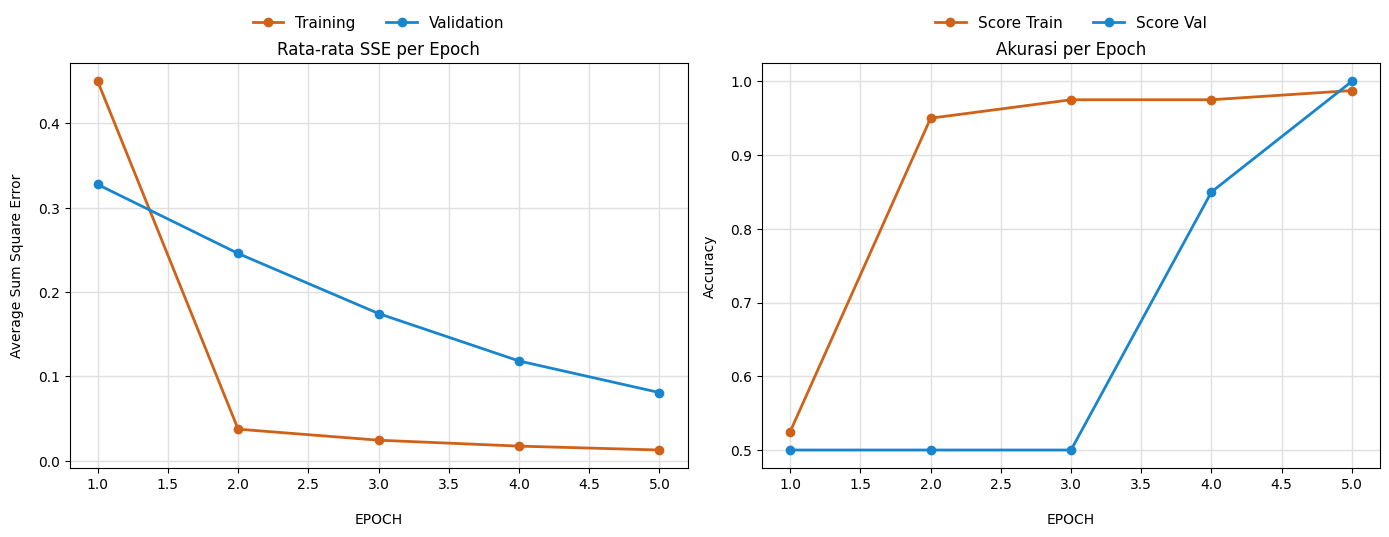

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

color_train = '#cf6218'
color_val = '#1885cf'

ax1.plot(summary_df["Epoch"], summary_df["Train Avg SSE"], marker='o', markersize=6, linewidth=2, color=color_train, label='Training')
ax1.plot(summary_df["Epoch"], summary_df["Val Avg SSE"], marker='o', markersize=6, linewidth=2, color=color_val, label='Validation')
ax1.set_title("Rata-rata SSE per Epoch")
ax1.set_xlabel("EPOCH", labelpad=15)
ax1.set_ylabel("Average Sum Square Error", labelpad=10)
ax1.grid(color='#e0e0e0', linestyle='-', linewidth=1)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

ax2.plot(summary_df["Epoch"], summary_df["Train Accuracy"], marker='o', markersize=6, linewidth=2, color=color_train, label='Score Train')
ax2.plot(summary_df["Epoch"], summary_df["Val Accuracy"], marker='o', markersize=6, linewidth=2, color=color_val, label='Score Val')
ax2.set_title("Akurasi per Epoch")
ax2.set_xlabel("EPOCH", labelpad=15)
ax2.set_ylabel("Accuracy", labelpad=10)
ax2.grid(color='#e0e0e0', linestyle='-', linewidth=1)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("grafik-perbandingan-slp.png", dpi=300, bbox_inches='tight')
plt.show()